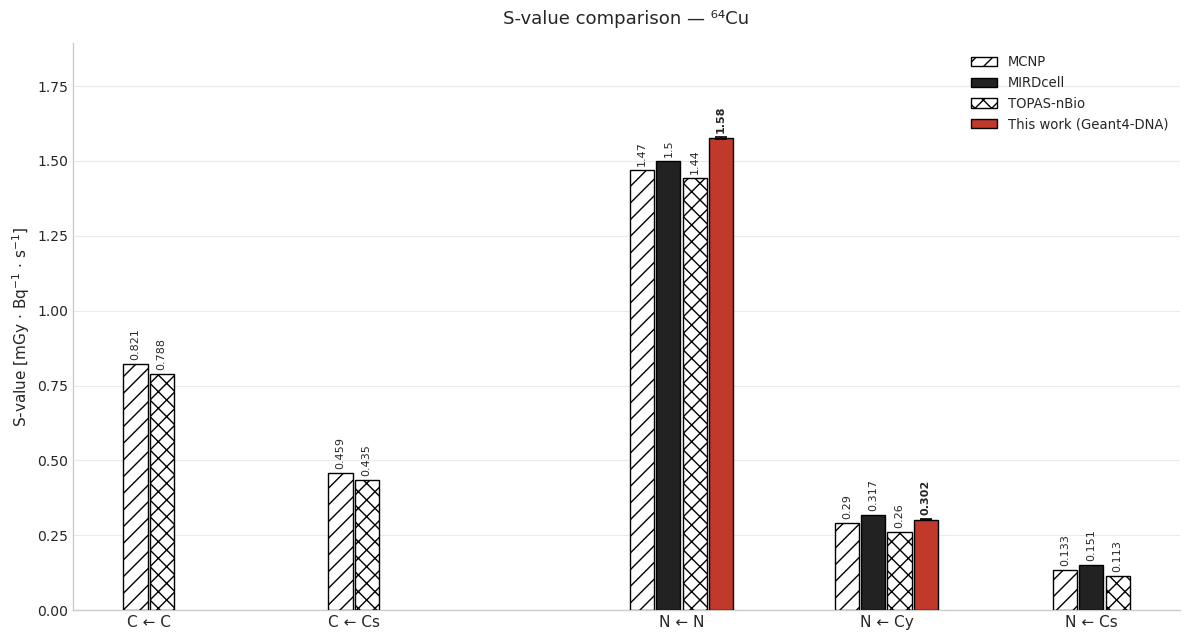

In [1]:
"""
confronto_svalue_cu64.py

Compares literature S-values for Cu-64 with the values obtained from your
own Geant4-DNA simulations, for five source<-target configurations
(C<-C, C<-Cs, N<-N, N<-Cy, N<-Cs).

Reference sources included:
  - TOPAS-nBio: Jalilian et al. (2022) and Carrasco-Hernandez et al. (2020),
    "Monte Carlo track-structure for the radionuclide Copper-64:
    characterization of S-values, nanodosimetry and quantification of
    direct damage to DNA", Phys. Med. Biol. 65(15):155005. The two works
    report matching TOPAS-nBio values (same underlying dataset).
  - MCNP and MIRDcell: values cited in Carrasco-Hernandez et al. (2020),
    Fig. 5, in turn taken from Cai Z., Kwon Y.L., Reilly R.M. (2017),
    "Monte Carlo N-Particle (MCNP) Modeling of the Cellular Dosimetry of
    64Cu: Comparison with MIRDcell S Values...", J. Nucl. Med. 58(2):339-345.
  - Geometry common to all sources: R_C = 5 um, R_N = 4 um (concentric
    water spheres).
  (Use this information for the LaTeX figure caption; it is not drawn on
  the plot itself.)

USAGE
-----
1. Update the SIMULATED dictionary below with the mean value over the 10
   batches (and, if available, the error) for the configuration you just
   completed -- the numbers you get from the analysis notebook
   (S_combined, err_stat, or the error rescaled by sqrt(chi2/dof)).
   Leave None for configurations not yet simulated: the corresponding bar
   is simply not drawn.
2. Run the script (`python confronto_svalue_cu64.py`): it produces a
   grouped bar chart with numeric labels above each bar.

Repeat step 1 every time you complete a new configuration, until all five
are filled in.
"""

import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1) Literature reference values, in mGy / (Bq * s).
#    None = value not reported/not available for that method in that
#    configuration (e.g. MIRDcell is not reported for C<-C and C<-Cs).
# ----------------------------------------------------------------------
CONFIGS = ["C \u2190 C", "C \u2190 Cs", "N \u2190 N", "N \u2190 Cy", "N \u2190 Cs"]

METHODS_REF = ["MCNP", "MIRDcell", "TOPAS-nBio"]

REFERENCE = {
    "C \u2190 C":  {"MCNP": 0.821, "MIRDcell": None, "TOPAS-nBio": 0.7879},
    "C \u2190 Cs": {"MCNP": 0.459, "MIRDcell": None, "TOPAS-nBio": 0.4351},
    "N \u2190 N":  {"MCNP": 1.47,  "MIRDcell": 1.5,   "TOPAS-nBio": 1.442},
    "N \u2190 Cy": {"MCNP": 0.29,  "MIRDcell": 0.317, "TOPAS-nBio": 0.2596},
    "N \u2190 Cs": {"MCNP": 0.133, "MIRDcell": 0.151, "TOPAS-nBio": 0.1127},
}

# Plot style for each reference method (black/white + hatch pattern, as in
# the original figure)
METHOD_STYLE = {
    "MCNP":       dict(facecolor="white", edgecolor="black", hatch="//"),
    "MIRDcell":   dict(facecolor="#222222", edgecolor="black", hatch=None),
    "TOPAS-nBio": dict(facecolor="white", edgecolor="black", hatch="xx"),
}
SIM_STYLE = dict(facecolor="#c0392b", edgecolor="black", hatch=None)
SIM_LABEL = "This work (Geant4-DNA)"

# ----------------------------------------------------------------------
# 2) YOUR SIMULATED VALUES -- UPDATE THIS SECTION AFTER EVERY RUN
#    value: mean over the 10 batches (mGy/(Bq*s), same unit as the
#           reference values)
#    err:   final error (e.g. rescaled by the sqrt(chi2/dof) factor)
#    Use {"value": None, "err": None} for a configuration not yet
#    completed.
# ----------------------------------------------------------------------
SIMULATED = {
    "C \u2190 C":  {"value": None,  "err": None},
    "C \u2190 Cs": {"value": None,  "err": None},
    "N \u2190 N":  {"value": 1.577, "err": 0.003},
    "N \u2190 Cy": {"value": 0.302, "err": 0.001},
    "N \u2190 Cs": {"value": None,  "err": None},
}

# ----------------------------------------------------------------------
# 3) Plot
# ----------------------------------------------------------------------
def plot_comparison(
    configs,
    reference,
    methods_ref,
    simulated,
    title="S-value comparison \u2014 \u2076\u2074Cu",
    ylabel=r"S-value [mGy $\cdot$ Bq$^{-1}$ $\cdot$ s$^{-1}$]",
    save_path=None,
):
    plt.style.use("seaborn-v0_8-whitegrid")

    bar_width = 0.16
    group_gap = 1.0   # extra spacing between the "C <- ..." group and the "N <- ..." group
    cat_gap = 0.25    # spacing between categories within the same group

    x_centers, cur, prev_key = [], 0.0, None
    for c in configs:
        key = c.split()[0]
        if prev_key is not None:
            cur += group_gap if key != prev_key else cat_gap
        x_centers.append(cur)
        cur += 1.0
        prev_key = key
    x_centers = np.array(x_centers)

    fig, ax = plt.subplots(figsize=(12, 6.5))

    legend_handles = {}

    for xc, c in zip(x_centers, configs):
        items = []  # (label, value, err, style)
        for m in methods_ref:
            v = reference[c].get(m)
            if v is not None:
                items.append((m, v, None, METHOD_STYLE[m]))
        sim_v = simulated[c]["value"]
        if sim_v is not None:
            items.append((SIM_LABEL, sim_v, simulated[c]["err"], SIM_STYLE))

        k = len(items)
        offsets = (np.arange(k) - (k - 1) / 2) * bar_width

        for off, (label, v, err, style) in zip(offsets, items):
            rect = ax.bar(
                xc + off, v, bar_width * 0.92,
                yerr=err, capsize=4 if err else 0,
                error_kw={"elinewidth": 1.2, "capthick": 1.2},
                zorder=3, **style,
            )
            if label not in legend_handles:
                legend_handles[label] = rect

            ax.annotate(
                f"{v:.3g}",
                xy=(xc + off, v + (err or 0)),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8, rotation=90,
                fontweight="bold" if label == SIM_LABEL else "normal",
            )

    ax.set_xticks(x_centers)
    ax.set_xticklabels(configs, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, pad=14)

    # Legend order: reference methods in the given order, then the simulation
    ordered_labels = [m for m in methods_ref if m in legend_handles]
    if SIM_LABEL in legend_handles:
        ordered_labels.append(SIM_LABEL)
    ax.legend(
        [legend_handles[l] for l in ordered_labels], ordered_labels,
        frameon=False, loc="upper right", fontsize=9.5, ncol=1,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

    all_vals = []
    for c in configs:
        all_vals += [v for v in reference[c].values() if v is not None]
        if simulated[c]["value"] is not None:
            all_vals.append(simulated[c]["value"])
    ax.set_ylim(0, max(all_vals) * 1.2)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    plot_comparison(CONFIGS, REFERENCE, METHODS_REF, SIMULATED, save_path="confronto_svalue_cu64.png")